# Scholarly Article Figures Code

In [1]:
import sys
from pathlib import Path

_root = Path.cwd()  # assumes notebook is run from the project root
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const
import heapq

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as Photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path
from cycler import cycler

current_directory = Path.cwd()
references_directory_path = "Installation_Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation_Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds


## Figures List + What is Needed:
- Figure type 1: Spaghetti plot for the H2-rich and one for O2-rich cases.
- Figure type 2: One panel. Albedo vs. wavelength for all three cases
- Figure type 3: Two panels. One panel is mini Neptune. The other is Earth. For both panels show contributions of ground, rayleigh scattering, clouds.
- Figure type 4: Two panels. One panel is mini Neptune. The other is Earth. Both show molecular contributions of molecules of interest. 

### (Extra case explored) Mini-Neptune K218b-like O2 Rich Case Files Needed:
- This was before the grid was done running, but does have a slightly weird PT profile.

Parameters:
- planet radius: 2.61x Earth
- **metallicity: 3.5x (logspace) x solar (~3000x solar metallicity)**
- tint: 155K
- semi major in AU: 1 AU
- **ctoO_solar: 0.01 x solar c/o ratio**
- kzz: 5 cm^2/s

### Case 1: Mini-Neptune H2/He Rich Case Files Needed:

Parameters:
- planet radius: 2x Earth Radius
- metallicity: 2x (logspace) x solar (~100x solar metallicity)
- tint: 50K
- semi major: 1 AU
- ctoO_solar: 0.7525 x solar c/o ratio
- kzz: 5 cm^2/s

### Case 2: Mini-Neptune O2 Rich Case from Grid (2x Earth Radius):

Parameters: Example from Grid
- planet radius: 2x Earth
- **metallicity: 3.125x (logspace) x solar (~3000x solar metallicity)**
- tint: 200K
- semi major in AU: 1 AU
- **ctoO_solar: 0.01 x solar c/o ratio**
- kzz: 5 cm^2/s

### Case 3: Mini-Neptune H2/CO Rich Case Files Needed:

Parameters: Example from Grid
- planet radius: 2x Earth
- **metallicity: 3.125x (logspace) x solar (~3000x solar metallicity)**
- tint: 200K
- semi major in AU: 1.5 AU
- **ctoO_solar: 1 x solar c/o ratio**
- kzz: 7 cm^2/s

## Figure 1: Spaghetti plot for Mini Neptune case(s). 

In [2]:
def find_pbot(sol=None, solaer=None, tol=0.9):

    """
    Parameters:
    pressures: ndarray
        Pressure at each atmospheric layer in dynes/cm^2
    H2Oaer: ndarray
        Mixing ratio of H2O aerosols.
    tol: float, optional
        The threshold value for which we define the beginning of the cloud, 
        by default 1e-4. 

    Returns:
    P_bottom: float
        The cloud bottom pressure in dynes/cm^2
        
    """

    pressure = sol['pressure']
    H2Oaer = solaer['H2Oaer']

    # There is no water cloud in the model, so we return None
    # For the cloud bottom of pressure

    if np.max(H2Oaer) < 1e-20:
        return None

    # Normalize so that max value is 1
    H2Oaer_normalized = H2Oaer/np.max(H2Oaer)

    # loop from bottom to top of atmosphere, cloud bottom pressure
    # defined as the index level where the normalized cloud mixing ratio
    # exeeds tol .

    ind = None
    
    for i, val in enumerate(H2Oaer_normalized):
        if val > tol:
            ind = i
            break

    if ind is None:
        raise Exception('A problem happened when trying to find the bottom of the cloud.')

    # Bottom of the cloud
    pbot = pressure[ind]

    return pbot

def plot_photochem_model_with_cloud(sol=None, soleq=None, ax1=None, show_legend=True):

    """
    Parameters:
        TBD
    """
    solaer_dict = {}

    for key, value in sol.items():
        if key.endswith('aer'):
            solaer_dict[key] = value
            
    print(solaer_dict.keys())
        
    pbot = find_pbot(sol=sol, solaer=solaer_dict)
    
    # Plot the Composition from Photochem
    if ax1 is None:
        fig, ax1 = plt.subplots(1,1,figsize=[8,6])
        
    
    species = ['CO2','He','H2O','CO', 'H2O2', 'NO', 'H2', 'O3', 'O2', 'NO2', 'OH', 'N2'] # What about CH4?
    species_aer = ['H2Oaer']

    custom_colors = ['red', 'green', 'blue', 'black', 'purple', 'grey', 'brown', 'orange', 'magenta', 'cyan', 'pink', 'limegreen']
    custom_colors_2 = ['skyblue']

    index_sol = 0
    index_soleq = 0
    
    for i,sp in enumerate(species):
        ax1.plot(sol[sp],np.array(sol['pressure'])/1e6, c=custom_colors[index_sol], label=sp)
        index_sol += 1

    for i, sp in enumerate(species_aer):
        ax1.plot(sol[sp], np.array(sol['pressure'])/1e6, c=custom_colors_2[index_soleq], label=sp)
        index_soleq += 1
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(1e-5,1)
    ax1.set_ylim(1000,1e-7)
    ax1.grid(alpha=0.4)
    ax1.set_xlabel('Mixing Ratio', fontsize=16)
    ax1.set_ylabel('Pressure (bars)', fontsize=16)
    ax1.set_yticks(10.0**np.arange(-6,2))
    ax1.tick_params(axis='x', labelsize=16) 
    ax1.tick_params(axis='y', labelsize=16)
    
    
    # Thickness of the box cloud
    ptop_earth = 0.6
    pbot_earth = 0.7
    logdp = np.log10(pbot_earth) - np.log10(ptop_earth)
    
    # Outline of the box cloud
    x_values = np.logspace(-8, 0, 10)
    y_values_bot = [pbot/10**6] * len(x_values)
    y_values_top = [((10**(np.log10(pbot/10**6) - logdp)))] * len(x_values)
    
    
    ax1.plot(x_values, y_values_bot, c='black', ls='--')
    ax1.plot(x_values, y_values_top, c='black', ls='--')
    ax1.fill_between(x_values, y_values_bot, y_values_top, color='gray', alpha=0.2, label='Cloud')

    if show_legend is True:
        ax1.legend(ncol=1,bbox_to_anchor=(1,1.0),loc='upper left')
     
    ax2 = ax1.twiny()
    ax2.set_xlim(0, 3000)
    ax2.set_xlabel('Temperature (K)', fontsize=16)
    ax2.tick_params(axis='x', labelsize=16)
    ax2.plot(sol['temperature'], (sol['pressure']/(1e6)), c='blue', ls='--',label='Photochem PT Profile')

    if ax1 is None:
        plt.title('K2-18b Around Sun (G-Star)', fontsize=20)
        plt.tight_layout()
        
        plt.show()

In [3]:
def get_top_molecules_for_case(photochem_data=None, top_n=15):

    excluded_suffixes = ('aer_sol', 'aer_soleq', 'soleq')
    excluded_exact = {
        'pressure_sol', 'temperature_sol', 'Kzz_sol',
        'pressure_soleq', 'temperature_soleq', 'Kzz_soleq',
        'converged_PC', 'converged_TP', 'temperature', 'pressure', 'Kzz'
    }

    molecule_means = {}

    sol = photochem_data['sol_dict']

    # Use sol's own pressure — it is always co-aligned with species arrays (100 levels
    # after interpolate_photochem_result_to_nlayers).  photochem_data['pressure'] may
    # come from a raw PICASO pkl (91 levels) and would cause a shape mismatch.
    pressure = sol['pressure']

    # Select where 0 < P < 10 bar
    valid = (pressure > 0) & (pressure < 10)

    if not np.any(valid):
        return [], {}

    for key in sol.keys():
        if key in excluded_exact:
            continue
        if key.endswith(excluded_suffixes):
            continue

        try:
            dataset = sol[key]
        except Exception:
            continue

        if not np.issubdtype(dataset.dtype, np.number):
            continue

        sliced = dataset[valid]
        mean_val = np.nanmean(sliced)
        molecule_means[key] = mean_val

    top_keys = heapq.nlargest(top_n, molecule_means, key=molecule_means.get)

    return top_keys, molecule_means

### Figure 2 & 3: One panel. Albedo vs. wavelength for Earth and Mini Neptune

In [4]:
WONG = ["#000000",
        "#0072B2",
        "#CC79A7",
        "#777777",
        "#009E73",
        "#56B4E9",
        "#D55E00",
        "#E69F00"]

WONG2 = ["#000000",
        "#0072B2",
        "#CC79A7",
        "#000000",
        "#009E73",
        "#56B4E9",
        "#D55E00",
        "#E69F00"]

WONG3 = ["#000000",
        "#0072B2",
        "#009E73",
        "#CC79A7"]

WONG_MiniNep_Gas = [
        "#0072B2",
        "#CC79A7",
        "#777777",
        "#009E73", 
        "#000000"]

WONG_Archean_Gas = [
        "#0072B2",
        "#CC79A7",
        "#777777", 
        "#000000"]


def plot_reflected_spectrum_final(
    wno=None,
    alb=None,
    inputs=None,
    legend_label=None,
    ax1=None,

    # --- STYLE CONTROL ---
    solid_indices=None,
    dashed_indices=None,

    # --- FILL CONTROL ---
    fill_indices=None,
    fill_between_ref=False,
    fill_ref_index=None,

    # --- LEGEND CONTROL ---
    use_patch_legend=True,
    show_legend=True,

    show_xlabel=False,
    colors=None,
):

    if colors is None:
        colors = WONG

    n = len(wno)

    solid_indices = set(solid_indices or [])
    dashed_indices = set(dashed_indices or [])
    fill_indices = set(fill_indices or [])

    standalone = ax1 is None
    if standalone:
        fig, ax1 = plt.subplots(1, 1, figsize=(7.25, 2.5))

    ax1.set_prop_cycle(cycler(color=colors))

    fill_ref_index = fill_ref_index if fill_ref_index is not None else 0

    legend_handles = []
    seen = set()

    for i in range(n):

        # --- debug ---
        if inputs is not None and inputs[i] is not None:
            print("_".join(map(str, inputs[i])))

        wl = 1e4 / np.array(wno[i])
        color = colors[i % len(colors)]

        # =====================================================
        # LINE STYLE CONTROL
        # =====================================================
        if i in solid_indices:
            linestyle = '-'
            lw = 2.0
        elif i in dashed_indices:
            linestyle = '--'
            lw = 1.0
        else:
            linestyle = '-'
            lw = 2.0

        # =====================================================
        # LEGEND LABEL CONTROL (IMPORTANT)
        # =====================================================
        label = legend_label[i] if show_legend else None

        # =====================================================
        # PLOT
        # =====================================================
        ax1.plot(
            wl,
            alb[i],
            linestyle=linestyle,
            lw=lw,
            color=color,
            label=label,
        )

        # =====================================================
        # FILL CONTROL
        # =====================================================
        if i in fill_indices:
            if fill_between_ref:
                ax1.fill_between(
                    wl,
                    np.array(alb[fill_ref_index]),
                    np.array(alb[i]),
                    color=color,
                    alpha=0.3,
                    linewidth=0,
                )
            else:
                ax1.fill_between(
                    wl,
                    alb[i],
                    color=color,
                    alpha=0.25,
                    linewidth=0,
                )

        # =====================================================
        # PATCH LEGEND BUILDING
        # =====================================================
        if show_legend and use_patch_legend:
            if legend_label[i] not in seen:
                legend_handles.append(
                    Patch(
                        facecolor=color,
                        edgecolor='black',
                        label=legend_label[i]
                    )
                )
                seen.add(legend_label[i])

    # =========================================================
    # AXES
    # =========================================================
    ax1.set_xlim(0.2, 2)
    ax1.set_ylabel("Albedo")

    if show_xlabel:
        ax1.set_xlabel("Wavelength ($\\mu$m)")

    # =========================================================
    # LEGEND OUTPUT
    # =========================================================
    if not show_legend:
        pass

    elif use_patch_legend:
        ax1.legend(handles=legend_handles, loc="upper right", fontsize=12)

    else:
        ax1.legend(loc="upper right", fontsize=12)

    if standalone:
        plt.tight_layout()
        plt.show()

In [5]:
def plot_reflected_spectrum_figure2(wno=None, alb=None, inputs=None, legend_label=None,
                                ax1=None, fill_curves=None, show_xlabel=False,
                                colors=None, fill_between_ref=False, fill_ref_index=None):
    if colors is None:
        colors = WONG

    standalone = ax1 is None
    if standalone:
        fig, ax1 = plt.subplots(1, 1, figsize=(7.25, 2.5))

    ax1.set_prop_cycle(cycler(color=colors))

    n = len(wno)
    fill_start = (n - fill_curves) if fill_curves is not None else n
    ref_index = fill_ref_index if fill_ref_index is not None else fill_start - 1

    for index in range(n):
        if inputs[index] is not None:
            print(f'{inputs[index][0]}_{inputs[index][1]}_{inputs[index][2]}_{inputs[index][3]}_{inputs[index][4]}_{inputs[index][5]}')
        else:
            print('Included Earth Plot that does not have inputs.')

        wl = 1e4 / np.array(wno[index])
        color = colors[index % len(colors)]

        if fill_curves is not None and index >= fill_start:
            line, = ax1.plot(wl, alb[index], linestyle='--', lw=0.8,
                             label=legend_label[index], color=color,
                             zorder=fill_start + (index - fill_start) * 2 + 1)
            if fill_between_ref:
                ref_alb = np.array(alb[ref_index])
                ax1.fill_between(wl, ref_alb, np.array(alb[index]), color=color, alpha=0.3,
                                 zorder=fill_start + (index - fill_start) * 2,
                                 linewidth=0)
            else:
                ax1.fill_between(wl, alb[index], color=color, alpha=0.25,
                                 zorder=fill_start + (index - fill_start) * 2,
                                 linewidth=0)
        else:
            ax1.plot(wl, alb[index], linestyle='-', lw=2,
                     label=legend_label[index], color=color,
                     zorder=n * 3)

    ax1.set_xlim(0.2, 2.5)
    ax1.set_ylabel('Albedo')

    if show_xlabel:
        ax1.set_xlabel('Wavelength ($\mu$m)')

    ax1.legend(loc='upper right', framealpha=0.85, fontsize=7, ncol=1)

    if standalone:
        plt.tight_layout()
        plt.show()

## Case 1

#### Figure 1: Spaghetti Plot of Photochemistry and PT Profile of H2/He Rich Mini-Neptune

In [6]:
### More Typical Mini-Neptune Case (H-He Rich)

with open('FinalPaperFigs/PhotochemPT_MiniNep_2.0_2.0_50.0_1.0_0.7525_5.0.pkl', 'rb') as f:
    H2HeRich_photochem_data = pickle.load(f)
    print(H2HeRich_photochem_data.keys())
    sol_H2HeRich = H2HeRich_photochem_data['sol_dict']
    soleq_H2HeRich = H2HeRich_photochem_data['soleq_dict']
    #temp_H2HeRich = H2HeRich_photochem_data['temperature']
    #pres_H2HeRich = H2HeRich_photochem_data['pressure']

    top_keys, molecule_means = get_top_molecules_for_case(photochem_data=H2HeRich_photochem_data, top_n=12)
    print(len(top_keys))
    print(top_keys)

    for top_key in top_keys:
        print(top_key, f'{molecule_means[f'{top_key}']}')

dict_keys(['sol_dict', 'soleq_dict', 'pressure', 'temperature'])
12
['H2', 'He', 'H', 'CO', 'CO2', 'C2H2', 'CH4', 'N2', 'H2O', 'C4H2', 'C2H6', 'C2H4']
H2 0.9478431395142197
He 0.05038343665414727
H 0.0007077915087546451
CO 0.00020123241406205315
CO2 0.00018449234348010332
C2H2 0.00017221744200222305
CH4 0.00014656675780288866
N2 0.00013933002487128915
H2O 0.00012663332336740443
C4H2 1.4420518273922465e-05
C2H6 7.38267441530198e-06
C2H4 1.4005211185712673e-06


dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])


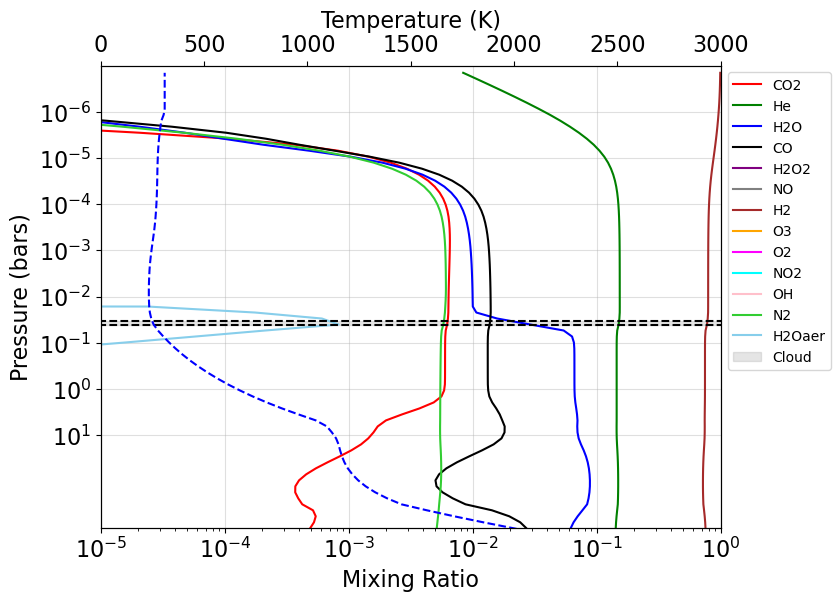

In [7]:
#### Figure 1:
plot_photochem_model_with_cloud(sol=sol_H2HeRich, soleq=soleq_H2HeRich)

#plt.savefig('SpaghettiPlot_H2HeRichMiniNep_fixedcld.png', dpi=300, bbox_inches='tight')

#### Figure 2 - 5 Data Loaded:

In [6]:
# ── Base H2HeRich gas planet (index 0) ──────────────────────────────────────
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_cld0.5.pkl', 'rb') as f:
    H2HeRich = pickle.load(f)
    wno_H2HeRich = H2HeRich['wno']
    alb_H2HeRich = H2HeRich['alb']

# ── H2HeRich variants (indices 7–13) ────────────────────────────────────────
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_cld0.5_noray.pkl', 'rb') as f:
    H2HeRich_noray = pickle.load(f)
    wno_H2HeRich_noray = H2HeRich_noray['wno']
    alb_H2HeRich_noray = H2HeRich_noray['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_nocld.pkl', 'rb') as f:
    H2HeRich_nocld = pickle.load(f)
    wno_H2HeRich_nocld = H2HeRich_nocld['wno']
    alb_H2HeRich_nocld = H2HeRich_nocld['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_noH2_cld0.5.pkl', 'rb') as f:
    H2HeRich_noH2 = pickle.load(f)
    wno_H2HeRich_noH2 = H2HeRich_noH2['wno']
    alb_H2HeRich_noH2 = H2HeRich_noH2['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_noCO2_cld0.5.pkl', 'rb') as f:
    H2HeRich_noCO2 = pickle.load(f)
    wno_H2HeRich_noCO2 = H2HeRich_noCO2['wno']
    alb_H2HeRich_noCO2 = H2HeRich_noCO2['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_noCH4_cld0.5.pkl', 'rb') as f:
    H2HeRich_noCH4 = pickle.load(f)
    wno_H2HeRich_noCH4 = H2HeRich_noCH4['wno']
    alb_H2HeRich_noCH4 = H2HeRich_noCH4['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_noH2O_cld0.5.pkl', 'rb') as f:
    H2HeRich_noH2O = pickle.load(f)
    wno_H2HeRich_noH2O = H2HeRich_noH2O['wno']
    alb_H2HeRich_noH2O = H2HeRich_noH2O['alb']

#with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_noHe_cld0.5.pkl', 'rb') as f:
#    H2HeRich_noHe = pickle.load(f)
#    wno_H2HeRich_noHe = H2HeRich_noHe['wno']
#    alb_H2HeRich_noHe = H2HeRich_noHe['alb']

# ── H2HeRich phase/cloud_frac variants (indices 24–28) ──────────────────────
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_cld0.25.pkl', 'rb') as f:
    H2HeRich_cld25 = pickle.load(f)
    wno_H2HeRich_cld25 = H2HeRich_cld25['wno']
    alb_H2HeRich_cld25 = H2HeRich_cld25['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_cld1.0.pkl', 'rb') as f:
    H2HeRich_cld100 = pickle.load(f)
    wno_H2HeRich_cld100 = H2HeRich_cld100['wno']
    alb_H2HeRich_cld100 = H2HeRich_cld100['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_phase50deg_cld0.5.pkl', 'rb') as f:
    H2HeRich_phase50deg = pickle.load(f)
    wno_H2HeRich_phase50deg = H2HeRich_phase50deg['wno']
    alb_H2HeRich_phase50deg = H2HeRich_phase50deg['alb']

with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_phase90deg_cld0.5.pkl', 'rb') as f:
    H2HeRich_phase90deg = pickle.load(f)
    wno_H2HeRich_phase90deg = H2HeRich_phase90deg['wno']
    alb_H2HeRich_phase90deg = H2HeRich_phase90deg['alb']

#with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_phase90deg_cld1.0.pkl', 'rb') as f:
#    H2HeRich_phase90deg_cld100 = pickle.load(f)
#    wno_H2HeRich_phase90deg_cld100 = H2HeRich_phase90deg_cld100['wno']
#    alb_H2HeRich_phase90deg_cld100 = H2HeRich_phase90deg_cld100['alb']

In [7]:
# ── Index 29: H2HeRich gas planet, phase=0°, cld=0.5, surface at 1 bar ──────
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_phase0deg_cld0.5.pkl', 'rb') as f:
    H2HeRich_phase0deg_surf1bar = pickle.load(f)
    wno_H2HeRich_phase0deg_surf1bar = H2HeRich_phase0deg_surf1bar['wno']
    alb_H2HeRich_phase0deg_surf1bar = H2HeRich_phase0deg_surf1bar['alb']

# ── Index 30: H2HeRich gas planet, phase=0°, cld=0.5, no NH3 ─────────────────
with open('data/RLS_results/RLS_H2HeRich_MiniNep_R15000_newopacity_phase0deg_noNH3_cld0.5.pkl', 'rb') as f:
    H2HeRich_phase0deg_noNH3 = pickle.load(f)
    wno_H2HeRich_phase0deg_noNH3 = H2HeRich_phase0deg_noNH3['wno']
    alb_H2HeRich_phase0deg_noNH3 = H2HeRich_phase0deg_noNH3['alb']

# ── Index 31: Archean Earth, phase=0°, no cloud, no surface (p=1000 bar) ─────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.0_psurf1000.0.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_nocld_nosurf = pickle.load(f)
    wno_ArcheanEarth_phase0deg_nocld_nosurf = ArcheanEarth_phase0deg_nocld_nosurf['wno']
    alb_ArcheanEarth_phase0deg_nocld_nosurf = ArcheanEarth_phase0deg_nocld_nosurf['albedo']

# ── Index 32: Archean Earth, phase=0°, no rayleigh, no cloud ─────────────────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.0_psurf1.0_noray.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_noray_nocld = pickle.load(f)
    wno_ArcheanEarth_phase0deg_noray_nocld = ArcheanEarth_phase0deg_noray_nocld['wno']
    alb_ArcheanEarth_phase0deg_noray_nocld = ArcheanEarth_phase0deg_noray_nocld['albedo']

# ── Index 33: Archean Earth, phase=0°, no rayleigh, no surface (p=1000 bar) ──
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.5_psurf1000.0_noray.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_noray_nosurf = pickle.load(f)
    wno_ArcheanEarth_phase0deg_noray_nosurf = ArcheanEarth_phase0deg_noray_nosurf['wno']
    alb_ArcheanEarth_phase0deg_noray_nosurf = ArcheanEarth_phase0deg_noray_nosurf['albedo']

# ── Index 34: Archean Earth, phase=0°, cld=0.5, surface=1 bar, no CO2 ────────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.5_psurf1.0_noCO2.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_noCO2 = pickle.load(f)
    wno_ArcheanEarth_phase0deg_noCO2 = ArcheanEarth_phase0deg_noCO2['wno']
    alb_ArcheanEarth_phase0deg_noCO2 = ArcheanEarth_phase0deg_noCO2['albedo']

# ── Index 35: Archean Earth, phase=0°, cld=0.5, surface=1 bar, no CH4 ────────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.5_psurf1.0_noCH4.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_noCH4 = pickle.load(f)
    wno_ArcheanEarth_phase0deg_noCH4 = ArcheanEarth_phase0deg_noCH4['wno']
    alb_ArcheanEarth_phase0deg_noCH4 = ArcheanEarth_phase0deg_noCH4['albedo']

# ── Index 36: Archean Earth, phase=0°, cld=0.5, surface=1 bar, no H2O ────────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.5_psurf1.0_noH2O.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_noH2O = pickle.load(f)
    wno_ArcheanEarth_phase0deg_noH2O = ArcheanEarth_phase0deg_noH2O['wno']
    alb_ArcheanEarth_phase0deg_noH2O = ArcheanEarth_phase0deg_noH2O['albedo']

# ── Index 37: Archean Earth, phase=0°, cld=0.5, surface=1 bar, no NH3 ────────
#with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.5_psurf1.0_noNH3.pkl', 'rb') as f:
#    ArcheanEarth_phase0deg_noNH3 = pickle.load(f)
#    wno_ArcheanEarth_phase0deg_noNH3 = ArcheanEarth_phase0deg_noNH3['wno']
#    alb_ArcheanEarth_phase0deg_noNH3 = ArcheanEarth_phase0deg_noNH3['albedo']


In [8]:
# ── Index 38: Archean Earth, phase=0°, cld=0.5, surface=1 bar, all gases ─────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.5_psurf1.0.pkl', 'rb') as f:
    ArcheanEarth_phase0deg = pickle.load(f)
    wno_ArcheanEarth_phase0deg = ArcheanEarth_phase0deg['wno']
    alb_ArcheanEarth_phase0deg = ArcheanEarth_phase0deg['albedo']

# ── Index 39: Archean Earth, phase=0°, cld=0.25, surface=1 bar ───────────────
#with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld0.25_psurf1.0.pkl', 'rb') as f:
#    ArcheanEarth_phase0deg_cld25 = pickle.load(f)
#    wno_ArcheanEarth_phase0deg_cld25 = ArcheanEarth_phase0deg_cld25['wno']
#    alb_ArcheanEarth_phase0deg_cld25 = ArcheanEarth_phase0deg_cld25['albedo']

# ── Index 40: Archean Earth, phase=0°, cld=1.0, surface=1 bar ────────────────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.0000_cld1.0_psurf1.0.pkl', 'rb') as f:
    ArcheanEarth_phase0deg_cld100 = pickle.load(f)
    wno_ArcheanEarth_phase0deg_cld100 = ArcheanEarth_phase0deg_cld100['wno']
    alb_ArcheanEarth_phase0deg_cld100 = ArcheanEarth_phase0deg_cld100['albedo']

# ── Index 41: Archean Earth, phase=30°, cld=1.0, surface=1 bar ───────────────
#with open('data/RLS_results/EarthSpectrum_ArcheanEarth_newopacityandwv_phase0.5236_cld1.0_psurf1.0.pkl', 'rb') as f:
#    ArcheanEarth_phase30deg_cld100 = pickle.load(f)
#    wno_ArcheanEarth_phase30deg_cld100 = ArcheanEarth_phase30deg_cld100['wno']
#    alb_ArcheanEarth_phase30deg_cld100 = ArcheanEarth_phase30deg_cld100['albedo']


In [9]:
# ── Archean Earth base redo (index 6) ────────────────────────────────────────
with open('data/RLS_results/EarthSpectrum_ArcheanEarth_ghostclde10_newopacityandwv_phase0.5236_cld0.5_psurf1.0.pkl', 'rb') as f:
    ArcheanEarth = pickle.load(f)
    wno_ArcheanEarth = ArcheanEarth['wno']
    alb_ArcheanEarth = ArcheanEarth['albedo']

#### Figure 2: Compare RLS of H2/He Rich Mini Neptune to Archean Earth

Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


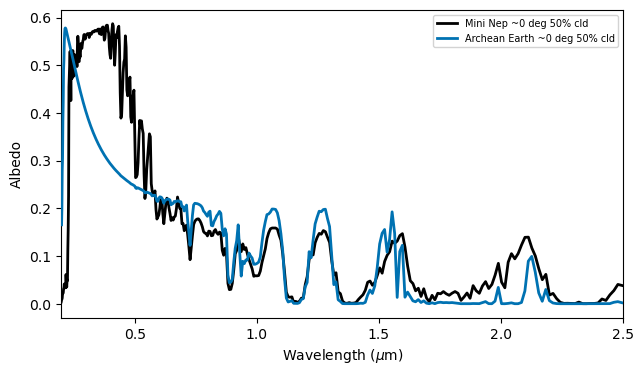

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(7.25, 4))

wno_all_SIMPLE = [wno_H2HeRich, wno_ArcheanEarth_phase0deg]
alb_all_SIMPLE = [alb_H2HeRich, alb_ArcheanEarth_phase0deg]
inputs_all_Archean_MinNep_Simple = [None, None]
legend_label_all_Archean_MinNep_Simple = ['Mini Nep ~0 deg 50% cld', 'Archean Earth ~0 deg 50% cld']

plot_reflected_spectrum_figure2(wno=wno_all_SIMPLE, alb=alb_all_SIMPLE,
                            inputs=inputs_all_Archean_MinNep_Simple,
                            legend_label=legend_label_all_Archean_MinNep_Simple,
                            ax1=ax, show_xlabel=True,
                           colors=WONG3)

leg = ax.get_legend()
plt.savefig('FinalPaperFigs/H2HeRichMinNep_ArcheanEarth_RLSSimpleCompFigure_UpdatedOpacity.pdf', dpi=300,
            bbox_inches='tight', bbox_extra_artists=[leg])



### Figure 3: Contributions of Clouds, Molecules, Rayleigh Scattering, and Gas to the Archean Spectrum

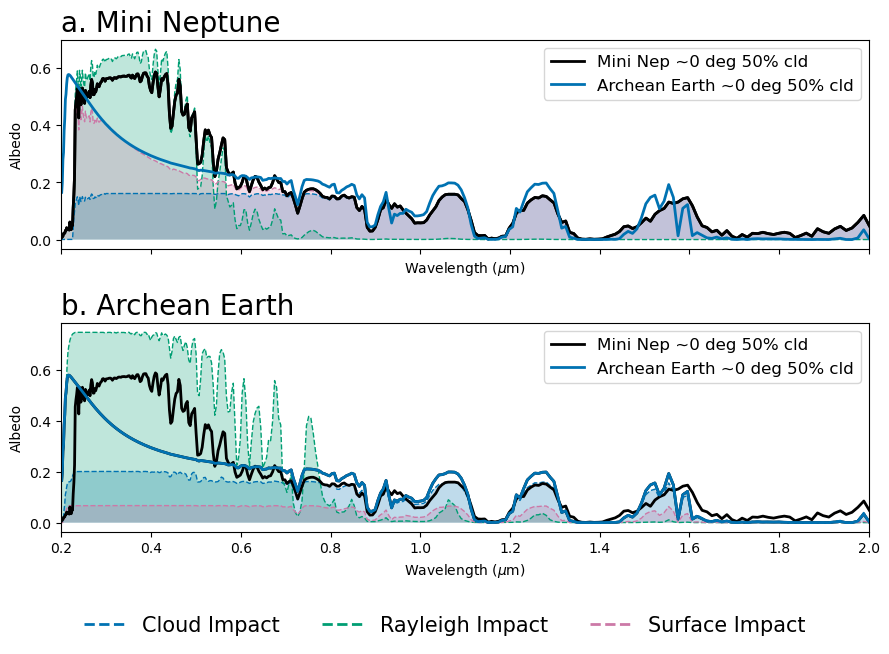

In [12]:
# AAS two-column width = 7.25 in; ~2.2 in per panel is comfortable for 4 panels

wno_all_SIMPLE = [wno_H2HeRich, wno_ArcheanEarth_phase0deg]
alb_all_SIMPLE = [alb_H2HeRich, alb_ArcheanEarth_phase0deg]
inputs_all_Archean_MinNep_Simple = [None, None]
legend_label_all_Archean_MinNep_Simple = ['Mini Nep ~0 deg 50% cld', 'Archean Earth ~0 deg 50% cld']

#Figure 1a:
wno_all_H2HeRich_MinNep = [wno_H2HeRich, wno_H2HeRich_noray, wno_H2HeRich_nocld, wno_H2HeRich_phase0deg_surf1bar]
alb_all_H2HeRich_MinNep = [alb_H2HeRich, alb_H2HeRich_noray, alb_H2HeRich_nocld, alb_H2HeRich_phase0deg_surf1bar]
inputs_all_H2HeRich_MinNep = [None, None, None, None]
legend_label_all_H2HeRich_MinNep = ['Mini Neptune', 'Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # Includes Surface means surface at 1 bar; each case is the following (gas + cld + no surf), (gas + ray + no surf), (gas + ray + cld + surface)


#Figure 1b:
wno_all_archeanearth = [wno_ArcheanEarth_phase0deg,  wno_ArcheanEarth_phase0deg_noray_nosurf, wno_ArcheanEarth_phase0deg_nocld_nosurf, wno_ArcheanEarth_phase0deg_noray_nocld]
alb_all_archeanearth = [alb_ArcheanEarth_phase0deg,  alb_ArcheanEarth_phase0deg_noray_nosurf, alb_ArcheanEarth_phase0deg_nocld_nosurf, alb_ArcheanEarth_phase0deg_noray_nocld]
inputs_all_archeanearth = [None, None, None, None, None]
legend_label_all_archeanearth = ['Archean Earth', 'Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # No surface means surface at 1000 bar; each case is the following (no cloud and no surface, no surface

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

plot_reflected_spectrum_final(wno=wno_all_H2HeRich_MinNep,     alb=alb_all_H2HeRich_MinNep,     inputs=inputs_all_H2HeRich_MinNep,     legend_label=legend_label_all_H2HeRich_MinNep, dashed_indices=[1,2,3], fill_indices=[1,2,3], ax1=axes[0], use_patch_legend=False, colors=WONG3, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_archeanearth,         alb=alb_all_archeanearth,         inputs=inputs_all_archeanearth,         legend_label=legend_label_all_archeanearth, dashed_indices=[1,2,3], fill_indices=[1,2,3], ax1=axes[1], use_patch_legend=False, colors=WONG3, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_SIMPLE,     alb=alb_all_SIMPLE,     inputs=inputs_all_Archean_MinNep_Simple,     legend_label=legend_label_all_Archean_MinNep_Simple, dashed_indices=None, fill_indices=None, ax1=axes[0], use_patch_legend=False, colors=WONG3, show_legend=True, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_SIMPLE,         alb=alb_all_SIMPLE,         inputs=inputs_all_Archean_MinNep_Simple,         legend_label=legend_label_all_Archean_MinNep_Simple, dashed_indices=None, fill_indices=None, ax1=axes[1], use_patch_legend=False, colors=WONG3, show_legend=True, show_xlabel=True)

axes[0].set_title("a. Mini Neptune", loc='left', fontsize=20)
axes[1].set_title("b. Archean Earth", loc='left', fontsize=20)

# Code to check elaboration in paper of certain features
#axes[0].set_title("a. Mini Neptune", loc='left', fontsize=15)
#axes[1].set_title("b. Archean Earth", loc='left', fontsize=15)

#axes[0].axvline(x=0.58, color='red', linestyle='--')
#axes[0].axvline(x=0.8, color='b', linestyle='--')
#axes[1].axvline(x=0.75, color='b', linestyle='--')
#axes[1].axhline(y=0.2, color='red', linestyle='--')

handles = []

legend_label_all_H2HeRich_MinNep_reduced = ['Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # Includes Surface means surface at 1 bar; each case is the following (gas + cld + no surf), (gas + ray + no surf), (gas + ray + cld + surface)
WONG3_reduced = ["#0072B2",
        "#009E73",
        "#CC79A7"]

labels = legend_label_all_H2HeRich_MinNep_reduced
colors = WONG3_reduced

for i in range(3):
    handles.append(
        Line2D(
            [0], [0],
            color=colors[i],
            lw=2,
            label=labels[i],
            linestyle='--'
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    labelspacing=1.5,
        bbox_to_anchor=(0.5, -0.1),
    fontsize=15
)


plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/H2HeRichMinNep_ArcheanEarth_ContributionsFigure_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')


### Figure 4: Contributions of Clouds, Molecules, Rayleigh Scattering, and Gas to the Archean Spectrum

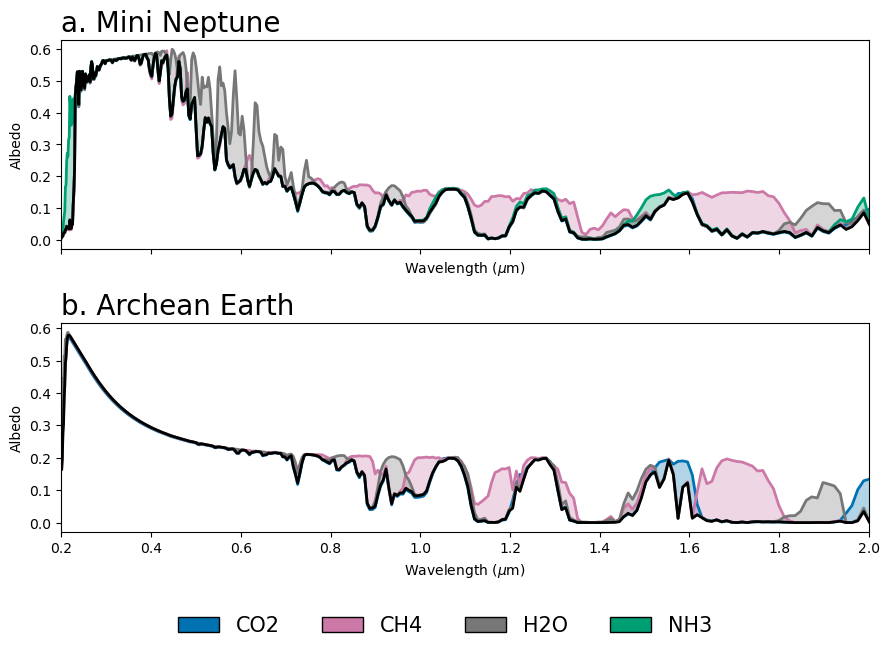

In [17]:
# AAS two-column width = 7.25 in; ~2.2 in per panel is comfortable for 4 panels

#Figure 1c:
wno_all_H2HeRich_MinNep_gas = [wno_H2HeRich_noCO2, wno_H2HeRich_noCH4, wno_H2HeRich_noH2O, wno_H2HeRich_phase0deg_noNH3, wno_H2HeRich,]
alb_all_H2HeRich_MinNep_gas = [alb_H2HeRich_noCO2, alb_H2HeRich_noCH4, alb_H2HeRich_noH2O, alb_H2HeRich_phase0deg_noNH3, alb_H2HeRich,]
inputs_all_H2HeRich_MinNep_gas = [None, None, None, None, None]
legend_label_all_H2HeRich_MinNep_gas = ['CO2', 'CH4', 'H2O', 'NH3', 'Mini Neptune'] # Means no CO2, no CH4, no H2O, no NH3

#Figure 1d:
wno_all_ArcheanEarth_gas = [wno_ArcheanEarth_phase0deg_noCO2, wno_ArcheanEarth_phase0deg_noCH4, wno_ArcheanEarth_phase0deg_noH2O, wno_ArcheanEarth_phase0deg,]
alb_all_ArcheanEarth_gas = [alb_ArcheanEarth_phase0deg_noCO2, alb_ArcheanEarth_phase0deg_noCH4, alb_ArcheanEarth_phase0deg_noH2O, alb_ArcheanEarth_phase0deg,]
inputs_all_ArcheanEarth_gas = [None, None, None, None]
legend_label_all_ArcheanEarth_gas = ['CO2', 'CH4', 'H2O', 'Archean Earth']


fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

plot_reflected_spectrum_final(wno=wno_all_H2HeRich_MinNep_gas, alb=alb_all_H2HeRich_MinNep_gas, inputs=inputs_all_H2HeRich_MinNep_gas, legend_label=legend_label_all_H2HeRich_MinNep_gas, fill_indices=[0,1,2,3], ax1=axes[0], fill_between_ref=True, fill_ref_index=4, colors=WONG_MiniNep_Gas, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_ArcheanEarth_gas, alb=alb_all_ArcheanEarth_gas, inputs=inputs_all_ArcheanEarth_gas, legend_label=legend_label_all_ArcheanEarth_gas, fill_indices=[0,1,2], ax1=axes[1], fill_between_ref = True, fill_ref_index=3, colors=WONG_Archean_Gas, show_legend=False, show_xlabel=True)

axes[0].set_title("a. Mini Neptune", loc='left', fontsize=20)
axes[1].set_title("b. Archean Earth", loc='left', fontsize=20)

# Code to check absorption feature description in paper
#axes[0].axvline(x=0.89, color='red', linestyle='--')
#axes[0].axvline(x=1.17, color='yellow', linestyle='--')
#axes[0].axvline(x=1, color='purple', linestyle='--')
#axes[0].axvline(x=1.7, color='pink', linestyle='--')
#axes[0].axvline(x=0.95, color='b', linestyle='--')
#axes[0].axvline(x=1.9, color='cyan', linestyle='--')
#axes[0].axhline(y=100, color='red', linestyle='--')

handles = []

labels = legend_label_all_H2HeRich_MinNep_gas  # <-- source of truth
colors = WONG_MiniNep_Gas

for i in range(4):  # first four only
    handles.append(
        Patch(
            facecolor=colors[i],
            edgecolor="black",
            label=labels[i],
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    labelspacing=1.5,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=15
)

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/H2HeRichMinNep_ArcheanEarth_MoleculeContributionsFigure_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')

### Extra Exploration of Clouds + Phases

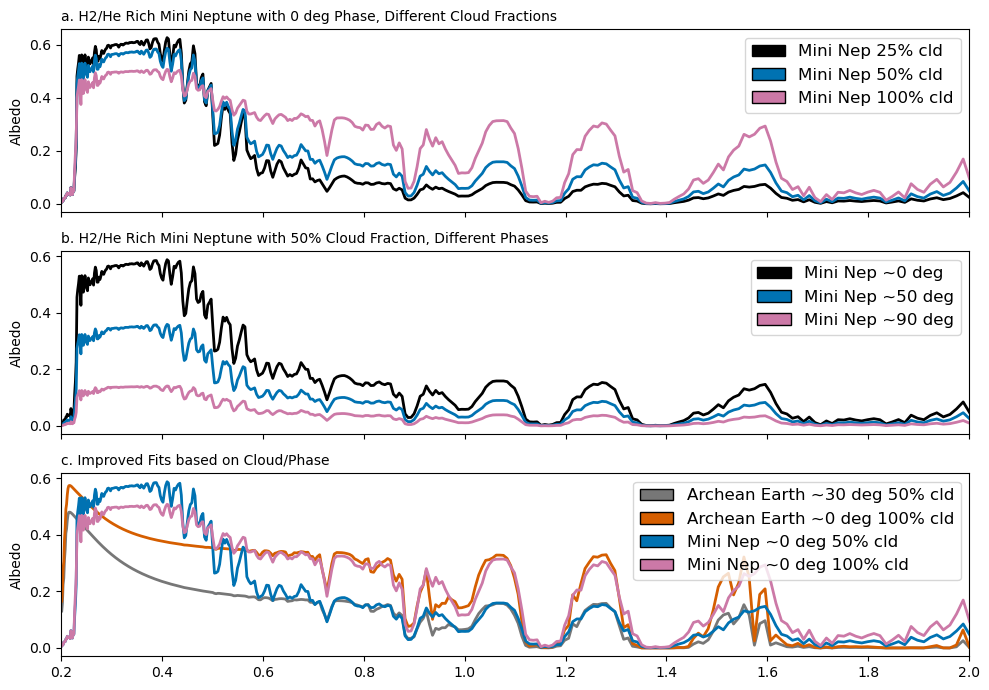

In [19]:
## Final Cloud Figure??

colors=WONG3

WONG = ["#000000",
        "#0072B2",
        "#CC79A7",
        "#777777",
        "#009E73",
        "#56B4E9",
        "#D55E00",
        "#E69F00"]

WONG4 = ["#777777",
        "#D55E00",
         "#0072B2",
        "#CC79A7"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

wno_all_H2HeRich_MinNep_cld = [wno_H2HeRich_cld25, wno_H2HeRich, wno_H2HeRich_cld100]
alb_all_H2HeRich_MinNep_cld = [alb_H2HeRich_cld25, alb_H2HeRich, alb_H2HeRich_cld100]
inputs_all_H2HeRich_MinNep_cld = [None, None, None]
legend_label_all_H2HeRich_MinNep_cld = ['Mini Nep 25% cld', 'Mini Nep 50% cld', 'Mini Nep 100% cld'] # 0 deg phase

plot_reflected_spectrum_final(wno=wno_all_H2HeRich_MinNep_cld, 
                            alb=alb_all_H2HeRich_MinNep_cld,
                            inputs=inputs_all_H2HeRich_MinNep_cld,
                            legend_label=legend_label_all_H2HeRich_MinNep_cld,
                           colors=WONG,
                           ax1=axes[0])

wno_all_H2HeRich_MinNep_phase = [wno_H2HeRich, wno_H2HeRich_phase50deg, wno_H2HeRich_phase90deg]
alb_all_H2HeRich_MinNep_phase = [alb_H2HeRich, alb_H2HeRich_phase50deg, alb_H2HeRich_phase90deg]
inputs_all_H2HeRich_MinNep_phase = [None, None, None]
legend_label_all_H2HeRich_MinNep_phase = ['Mini Nep ~0 deg' , 'Mini Nep ~50 deg' , 'Mini Nep ~90 deg'] # 50% cld

plot_reflected_spectrum_final(wno=wno_all_H2HeRich_MinNep_phase, 
                            alb=alb_all_H2HeRich_MinNep_phase,
                            inputs=inputs_all_H2HeRich_MinNep_phase,
                            legend_label=legend_label_all_H2HeRich_MinNep_phase,
                           colors=WONG,
                           ax1=axes[1])

wno_all_H2HeRich_MinNep_cld_phase = [wno_ArcheanEarth, wno_ArcheanEarth_phase0deg_cld100, wno_H2HeRich, wno_H2HeRich_cld100]
alb_all_H2HeRich_MinNep_cld_phase = [alb_ArcheanEarth, alb_ArcheanEarth_phase0deg_cld100, alb_H2HeRich,  alb_H2HeRich_cld100]
inputs_all_H2HeRich_MinNep_cld_phase = [None, None, None, None]
legend_label_all_H2HeRich_MinNep_cld_phase = ['Archean Earth ~30 deg 50% cld', 'Archean Earth ~0 deg 100% cld', 'Mini Nep ~0 deg 50% cld', 'Mini Nep ~0 deg 100% cld'] 

plot_reflected_spectrum_final(wno=wno_all_H2HeRich_MinNep_cld_phase, 
                            alb=alb_all_H2HeRich_MinNep_cld_phase,
                            inputs=inputs_all_H2HeRich_MinNep_cld_phase,
                            legend_label=legend_label_all_H2HeRich_MinNep_cld_phase,
                           colors=WONG4,
                           ax1=axes[2])


axes[0].set_title("a. H2/He Rich Mini Neptune with 0 deg Phase, Different Cloud Fractions", loc='left', fontsize=10)
axes[1].set_title("b. H2/He Rich Mini Neptune with 50% Cloud Fraction, Different Phases", loc='left', fontsize=10)
axes[2].set_title("c. Improved Fits based on Cloud/Phase", loc='left', fontsize=10)

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/H2HeRichMinNep_ArcheanEarth_Phase&CloudChanges_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')


## Case 2:

#### Figure 1: Spaghetti Plot of Photochemistry and PT Profile of O2 Rich Mini-Neptune

In [20]:
rad = 2
metal = 3.125
tint = 200
semi_major = 1
ctoO = 0.01
Kzz = 5
photochem_filename = 'results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5'

print(rad, metal, tint, semi_major, ctoO, Kzz)

sol_2_3125_200_1_001_5, soleq_2_3125_200_1_001_5, PT_list_2_3125_200_1_001_5, convergence_PC_2_3125_200_1_001_5, convergence_TP_2_3125_200_1_001_5 = Reflected_Spectra.find_Photochem_match(filename=photochem_filename,  rad_plan=rad, log10_planet_metallicity=metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, gridvals= Photochem_grid.get_gridvals_Photochem())

2 3.125 200 1 0.01 5
Was able to successfully find your input parameters in the PICASO TP profile grid!


In [21]:
photochem_data_case2 = {'pressure': PT_list_2_3125_200_1_001_5[0],
                'temperature':  PT_list_2_3125_200_1_001_5[1],
                'sol_dict': sol_2_3125_200_1_001_5,
                'soleq_dict': soleq_2_3125_200_1_001_5}

top_keys, molecule_means = get_top_molecules_for_case(photochem_data=photochem_data_case2, top_n=12)
print(len(top_keys))
print(top_keys)

for top_key in top_keys:
    print(top_key, f'{molecule_means[f'{top_key}']}')

12
['He', 'O2', 'O', 'N2', 'CO2', 'N', 'CO', 'H', 'O3', 'N2D', 'H2O', 'NO']
He 0.7448654354784764
O2 0.17303863673125824
O 0.038858332079654306
N2 0.038589394299193724
CO2 0.003006511443777787
N 0.0001875346781024813
CO 0.00015361458852028862
H 7.585311881958633e-06
O3 7.144206725847915e-07
N2D 2.0927882595957356e-07
H2O 1.8163901503474755e-07
NO 3.5657762306748976e-08


In [22]:
print(len(photochem_data_case2['pressure']))
print(len(photochem_data_case2['sol_dict']['O']))

100
100


dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])


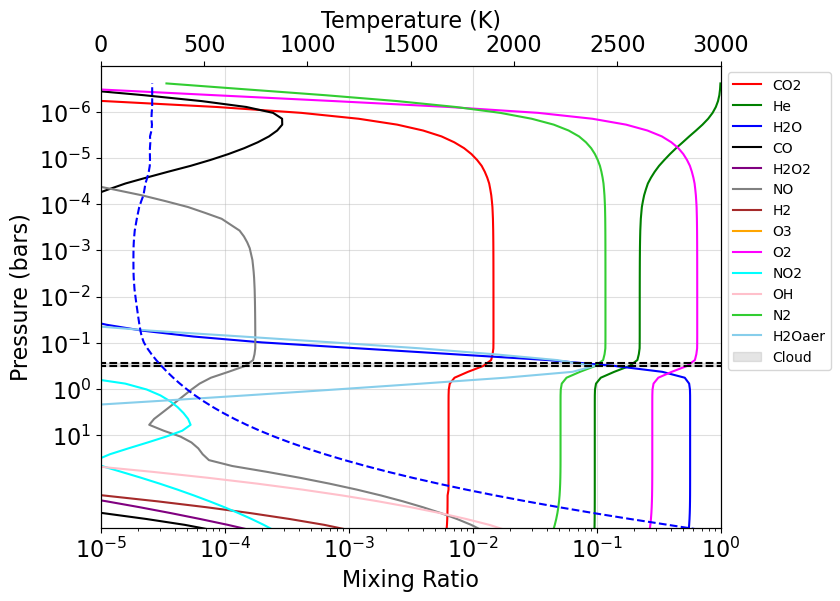

In [24]:
plot_photochem_model_with_cloud(sol=sol_2_3125_200_1_001_5, soleq=soleq_2_3125_200_1_001_5)
plt.savefig('FinalPaperFigs/SpaghettiPlot_O2Rich_MiniNep.pdf', dpi=300, bbox_inches='tight')

#### Figure 2 - 5 Data Loaded:

In [25]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# --- Case 2: O2-rich Mini-Neptune ---
c2_standard  = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_cld0.5.pkl')
c2_nocld     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_nocld.pkl')
c2_noray     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_cld0.5_noray.pkl')
c2_surf1     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_psurf1_cld0.5.pkl')
c2_noCO2     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noCO2_cld0.5.pkl')
c2_noCH4     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noCH4_cld0.5.pkl')
c2_noH2O     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noH2O_cld0.5.pkl')
c2_noNH3     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noNH3_cld0.5.pkl')
c2_noO3      = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noO3_cld0.5.pkl')
c2_noO2     = load_pkl('data/RLS_results/RLS_O2Rich_MiniNep_noO2_cld0.5.pkl')

# --- Modern Earth (gas planet keys: wno, fpfs, alb; earth keys: wno, fpfs, albedo) ---
_ep = 'data/RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf1.0'
me_noCO2     = load_pkl(f'{_ep}_noCO2.pkl')
me_noCH4     = load_pkl(f'{_ep}_noCH4.pkl')
me_noH2O     = load_pkl(f'{_ep}_noH2O.pkl')
me_noNH3     = load_pkl(f'{_ep}_noNH3.pkl')
me_noO3      = load_pkl(f'{_ep}_noO3.pkl')
me_noO2     = load_pkl('data/RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf1.0_noO2.pkl')

me_standard  = load_pkl('data/RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf1.0.pkl')
me_gas_ray       = load_pkl('data/RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.0_psurf1000.0.pkl')         # idx 24 — gas + Rayleigh only
me_cld_gas       = load_pkl('data/RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.5_psurf1000.0_noray.pkl')   # idx 25 — cloud + gas only
me_surf_gas      = load_pkl('data/RLS_results/EarthSpectrum_ModernEarth_phase0.5236_cld0.0_psurf1.0_noray.pkl')      # idx 26 — surface + gas only

#### Figure 2: Compare RLS of O2 Rich Mini Neptune to Modern Earth

Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


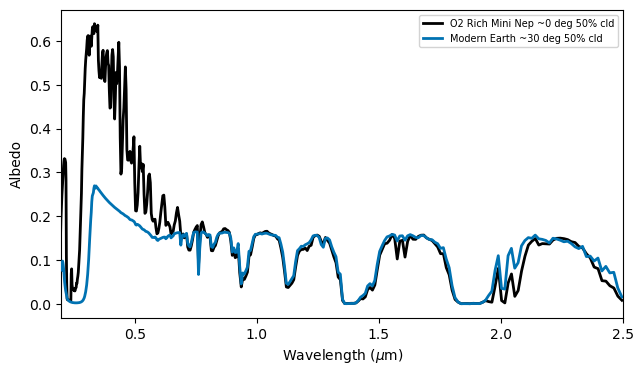

In [27]:
fig, ax = plt.subplots(1, 1, figsize=(7.25, 4))

wno_all_c2_standard = [c2_standard['wno'], me_standard['wno']]
alb_all_c2_standard = [c2_standard['alb'], me_standard['albedo']]
inputs_all_Modern_O2MinNep = [None, None]
legend_label_all_Modern_O2MinNep = ['O2 Rich Mini Nep ~0 deg 50% cld', 'Modern Earth ~30 deg 50% cld']

plot_reflected_spectrum_figure2(wno=wno_all_c2_standard, alb=alb_all_c2_standard,
                            inputs=inputs_all_Modern_O2MinNep,
                            legend_label=legend_label_all_Modern_O2MinNep,
                            ax1=ax, show_xlabel=True,
                           colors=WONG3)

leg = ax.get_legend()
plt.savefig('FinalPaperFigs/O2RichMinNep_ModernEarth_RLSSimpleCompFigure_UpdatedOpacity.pdf', dpi=300,
            bbox_inches='tight', bbox_extra_artists=[leg])



### Figure 3: Contributions of Clouds, Molecules, Rayleigh Scattering, and Gas to the Archean Spectrum

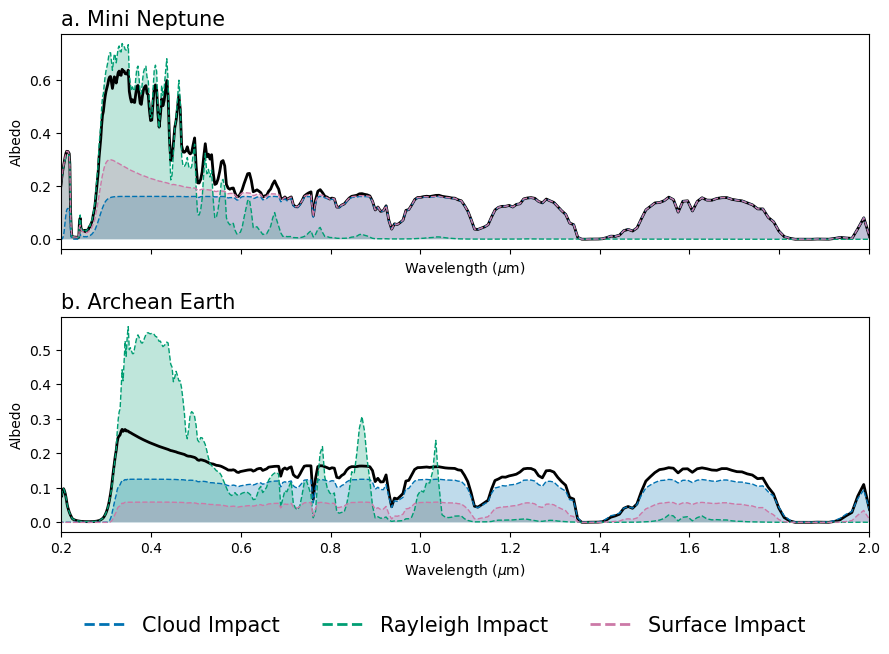

In [29]:
#Figure 1a:
wno_all_O2Rich_MinNep = [c2_standard['wno'], c2_noray['wno'], c2_nocld['wno'], c2_surf1['wno']]
alb_all_O2Rich_MinNep = [c2_standard['alb'], c2_noray['alb'], c2_nocld['alb'], c2_surf1['alb']]
inputs_all_O2Rich_MinNep = [None, None, None, None]
legend_label_all_O2Rich_MinNep = ['Mini Neptune', 'Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # Includes Surface means surface at 1 bar; each case is the following (gas + cld + no surf), (gas + ray + no surf), (gas + ray + cld + surface)


#Figure 1b:
wno_all_modernearth = [me_standard['wno'],  me_cld_gas['wno'], me_gas_ray['wno'], me_surf_gas['wno']]
alb_all_modernearth = [me_standard['albedo'],  me_cld_gas['albedo'], me_gas_ray['albedo'], me_surf_gas['albedo']]
inputs_all_modernearth = [None, None, None, None, None]
legend_label_all_modernearth = ['Modern Earth', 'Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # No surface means surface at 1000 bar; each case is the following (no cloud and no surface, no surface

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

plot_reflected_spectrum_final(wno=wno_all_O2Rich_MinNep,     alb=alb_all_O2Rich_MinNep,     inputs=inputs_all_O2Rich_MinNep,     legend_label=legend_label_all_O2Rich_MinNep, dashed_indices=[1,2,3], fill_indices=[1,2,3], ax1=axes[0], use_patch_legend=False, colors=WONG3, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_modernearth,         alb=alb_all_modernearth,         inputs=inputs_all_modernearth,         legend_label=legend_label_all_modernearth, dashed_indices=[1,2,3], fill_indices=[1,2,3], ax1=axes[1], use_patch_legend=False, colors=WONG3, show_legend=False, show_xlabel=True)

axes[0].set_title("a. Mini Neptune", loc='left', fontsize=15)
axes[1].set_title("b. Archean Earth", loc='left', fontsize=15)

# Added lines to check analysis in paper
#axes[0].axvline(x=0.58, color='red', linestyle='--')
#axes[0].axvline(x=0.8, color='b', linestyle='--')
#axes[1].axvline(x=0.75, color='b', linestyle='--')
#axes[1].axhline(y=0.2, color='red', linestyle='--')

handles = []

legend_label_all_O2Rich_MinNep_reduced = ['Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # Includes Surface means surface at 1 bar; each case is the following (gas + cld + no surf), (gas + ray + no surf), (gas + ray + cld + surface)
WONG3_reduced = ["#0072B2",
        "#009E73",
        "#CC79A7"]

labels = legend_label_all_O2Rich_MinNep_reduced
colors = WONG3_reduced

for i in range(3):
    handles.append(
        Line2D(
            [0], [0],
            color=colors[i],
            lw=2,
            label=labels[i],
            linestyle='--'
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    labelspacing=1.5,
        bbox_to_anchor=(0.5, -0.1),
    fontsize=15
)


plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/O2RichMinNep_ModernEarth_ContributionsFigure_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')


### Figure 4: Contributions of Clouds, Molecules, Rayleigh Scattering, and Gas to the Archean Spectrum

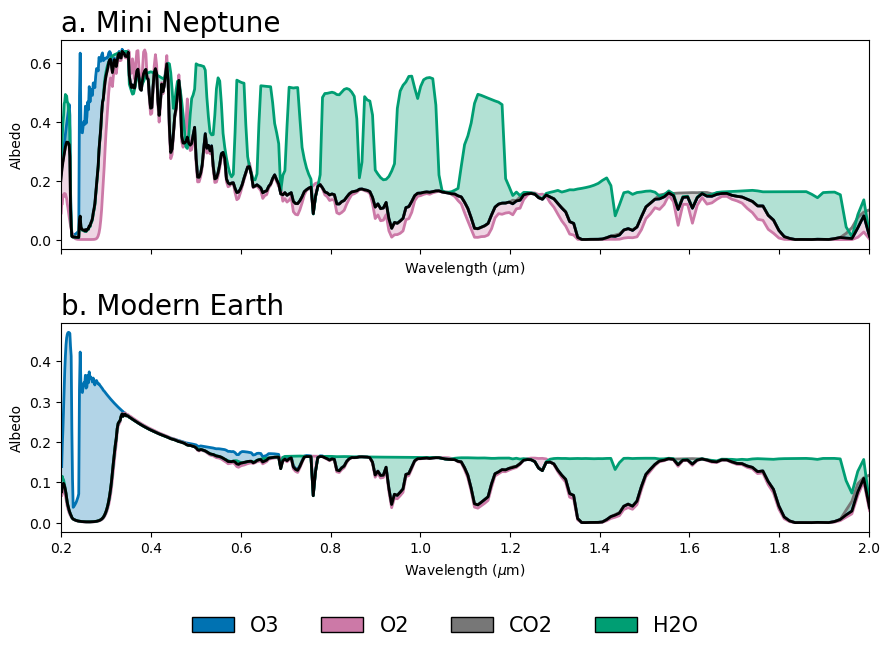

In [60]:
# AAS two-column width = 7.25 in; ~2.2 in per panel is comfortable for 4 panels

#Figure 1c:
wno_all_O2Rich_MinNep_gas = [c2_noO3['wno'], c2_noO2['wno'], c2_noCO2['wno'], c2_noH2O['wno'], c2_standard['wno']]
alb_all_O2Rich_MinNep_gas = [c2_noO3['alb'], c2_noO2['alb'], c2_noCO2['alb'], c2_noH2O['alb'], c2_standard['alb']]
inputs_all_O2Rich_MinNep_gas = [None, None, None, None, None]
legend_label_all_O2Rich_MinNep_gas = ['O3', 'O2', 'CO2', 'H2O', 'Mini Neptune (0 deg)'] # Means no CO2, no CH4, no H2O, no NH3

#Figure 1d:
wno_all_ModernEarth_gas = [me_noO3['wno'], me_noO2['wno'], me_noCO2['wno'], me_noH2O['wno'], me_standard['wno']]
alb_all_ModernEarth_gas = [me_noO3['albedo'], me_noO2['albedo'], me_noCO2['albedo'], me_noH2O['albedo'], me_standard['albedo']]
inputs_all_ModernEarth_gas = [None, None, None, None, None]
legend_label_all_ModernEarth_gas = ['O3', 'O2', 'CO2', 'H2O', 'Modern Earth (30 deg)']


fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

plot_reflected_spectrum_final(wno=wno_all_O2Rich_MinNep_gas, alb=alb_all_O2Rich_MinNep_gas, inputs=inputs_all_O2Rich_MinNep_gas, legend_label=legend_label_all_O2Rich_MinNep_gas, fill_indices=[0,1,2,3], ax1=axes[0], fill_between_ref=True, fill_ref_index=4, colors=WONG_MiniNep_Gas, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_ModernEarth_gas, alb=alb_all_ModernEarth_gas, inputs=inputs_all_ModernEarth_gas, legend_label=legend_label_all_ModernEarth_gas, fill_indices=[0,1,2, 3], ax1=axes[1], fill_between_ref = True, fill_ref_index=4, colors=WONG_MiniNep_Gas, show_legend=False, show_xlabel=True)

axes[0].set_title("a. Mini Neptune", loc='left', fontsize=20)
axes[1].set_title("b. Modern Earth", loc='left', fontsize=20)

# Way to add lines to check understanding
#axes[0].axvline(x=0.89, color='red', linestyle='--')
#axes[0].axvline(x=1.17, color='yellow', linestyle='--')
#axes[0].axvline(x=1, color='purple', linestyle='--')
#axes[0].axvline(x=1.7, color='pink', linestyle='--')
#axes[0].axvline(x=0.95, color='b', linestyle='--')
#axes[0].axvline(x=1.9, color='cyan', linestyle='--')
#axes[0].axhline(y=100, color='red', linestyle='--')

handles = []

labels = legend_label_all_O2Rich_MinNep_gas  # <-- source of truth
colors = WONG_MiniNep_Gas

for i in range(4):  # first four only
    handles.append(
        Patch(
            facecolor=colors[i],
            edgecolor="black",
            label=labels[i],
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    labelspacing=1.5,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=15
)

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/O2RichMinNep_ModernEarth_MoleculeContributionsFigure_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')

## Case 3:

#### Figure 1: Spaghetti Plot of Photochemistry and PT Profile of H2/CO Rich Mini-Neptune

In [39]:
rad = 2
metal = 3.125
tint = 200
semi_major = 1.5
ctoO = 1
Kzz = 7
photochem_filename = 'results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5'

print(rad, metal, tint, semi_major, ctoO, Kzz)

sol_2_3125_200_15_1_7, soleq_2_3125_200_15_1_7, PT_list_2_3125_200_15_1_7, convergence_PC_2_3125_200_15_1_7, convergence_TP_2_3125_200_15_1_7 = Reflected_Spectra.find_Photochem_match(filename=photochem_filename,  rad_plan=rad, log10_planet_metallicity=metal, tint=tint, semi_major=semi_major, ctoO=ctoO, Kzz=Kzz, gridvals= Photochem_grid.get_gridvals_Photochem())

2 3.125 200 1.5 1 7
Was able to successfully find your input parameters in the PICASO TP profile grid!


In [40]:
photochem_data_case3 = {'pressure': PT_list_2_3125_200_15_1_7[0],
                'temperature':  PT_list_2_3125_200_15_1_7[1],
                'sol_dict': sol_2_3125_200_15_1_7,
                'soleq_dict': soleq_2_3125_200_15_1_7}

top_keys, molecule_means = get_top_molecules_for_case(photochem_data=photochem_data_case3, top_n=12)
print(len(top_keys))
print(top_keys)

for top_key in top_keys:
    print(top_key, f'{molecule_means[f'{top_key}']}')

12
['H2', 'CO', 'He', 'N2', 'CO2', 'CH4', 'H', 'C2H2', 'C2H4', 'C2H6', 'H2O', 'CH3']
H2 0.49401647063418136
CO 0.26064537972433355
He 0.12583117181061898
N2 0.059463667134319685
CO2 0.043107942594847445
CH4 0.016473640808486806
H 0.0002450319096879119
C2H2 7.71452973054162e-05
C2H4 5.296788553997414e-05
C2H6 2.168790802719337e-05
H2O 9.52260717854793e-06
CH3 9.017651514616876e-06


dict_keys(['C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'CH4aer', 'CO2aer', 'H2Oaer', 'HCCCNaer', 'HCNaer', 'N2Oaer', 'NH3aer'])


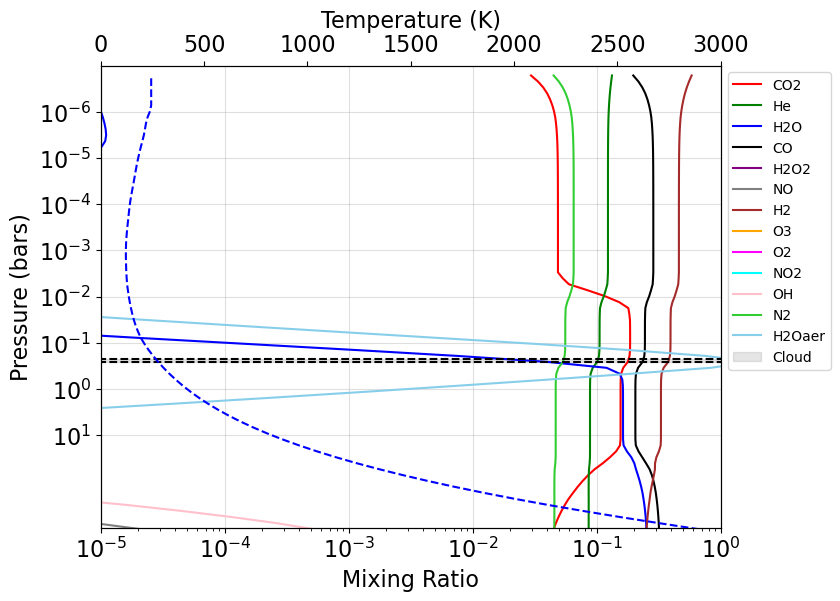

In [42]:
plot_photochem_model_with_cloud(sol=sol_2_3125_200_15_1_7, soleq=soleq_2_3125_200_15_1_7)
plt.savefig('FinalPaperFigs/SpaghettiPlot_H2CORich_MiniNep.pdf', dpi=300, bbox_inches='tight')

### Figure 2-5 Data Loaded

In [44]:
# --- Case 3: H2/CO-rich Mini-Neptune ---
c3_standard  = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_cld0.5.pkl')
c3_nocld     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_nocld.pkl')
c3_noray     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_cld0.5_noray.pkl')
c3_surf1     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_psurf1_cld0.5.pkl')
c3_noCO2     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_noCO2_cld0.5.pkl')
c3_noCH4     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_noCH4_cld0.5.pkl')
c3_noH2O     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_noH2O_cld0.5.pkl')
c3_noNH3     = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_noNH3_cld0.5.pkl')
c3_noO3      = load_pkl('data/RLS_results/RLS_H2CORich_MiniNep_noO3_cld0.5.pkl')

### Figure 2: Compare RLS of O2 Rich Mini Neptune to Modern Earth

Included Earth Plot that does not have inputs.
Included Earth Plot that does not have inputs.


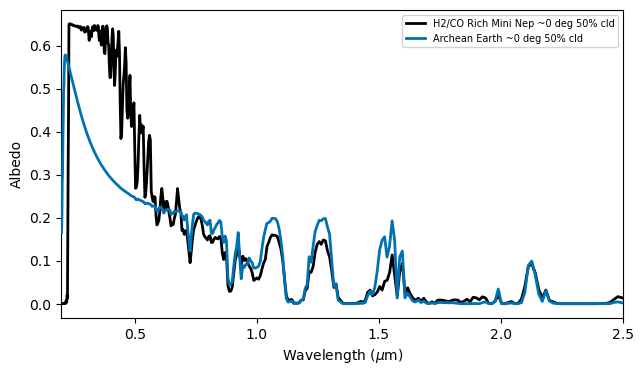

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(7.25, 4))

wno_all_c3_standard = [c3_standard['wno'], me_standard['wno']]
alb_all_SIMPLE = [c3_standard['alb'], alb_ArcheanEarth_phase0deg]
inputs_all_Archean_MinNep_Simple = [None, None]
legend_label_all_Modern_H2COMinNep = ['H2/CO Rich Mini Nep ~0 deg 50% cld', 'Archean Earth ~0 deg 50% cld']

plot_reflected_spectrum_figure2(wno=wno_all_c3_standard, alb=alb_all_SIMPLE,
                            inputs=inputs_all_Archean_MinNep_Simple,
                            legend_label=legend_label_all_Modern_H2COMinNep,
                            ax1=ax, show_xlabel=True,
                           colors=WONG3)

leg = ax.get_legend()
plt.savefig('FinalPaperFigs/H2CORichMinNep_ModernEarth_RLSSimpleCompFigure_UpdatedOpacity.pdf', dpi=300,
            bbox_inches='tight', bbox_extra_artists=[leg])



### Figure 3: Contributions of Clouds, Molecules, Rayleigh Scattering, and Gas to the Archean Spectrum

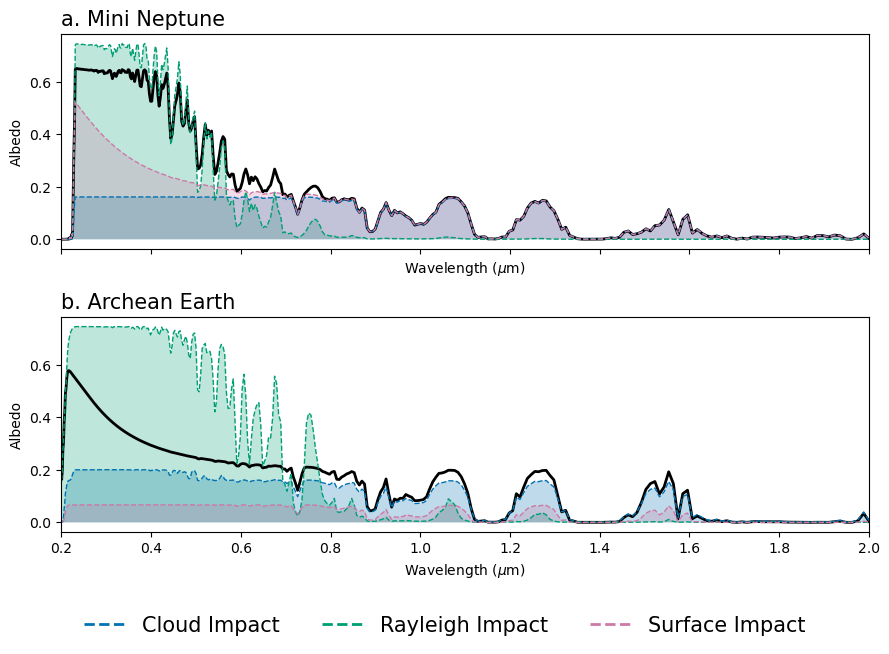

In [51]:
# AAS two-column width = 7.25 in; ~2.2 in per panel is comfortable for 4 panels
#Figure 1a:
wno_all_H2CORich_MinNep = [c3_standard['wno'], c3_noray['wno'], c3_nocld['wno'], c3_surf1['wno']]
alb_all_H2CORich_MinNep = [c3_standard['alb'], c3_noray['alb'], c3_nocld['alb'], c3_surf1['alb']]
inputs_all_H2CORich_MinNep = [None, None, None, None]
legend_label_all_H2CORich_MinNep = ['Mini Neptune', 'Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # Includes Surface means surface at 1 bar; each case is the following (gas + cld + no surf), (gas + ray + no surf), (gas + ray + cld + surface)


#Figure 1b:
wno_all_archeanearth = [wno_ArcheanEarth_phase0deg,  wno_ArcheanEarth_phase0deg_noray_nosurf, wno_ArcheanEarth_phase0deg_nocld_nosurf, wno_ArcheanEarth_phase0deg_noray_nocld]
alb_all_archeanearth = [alb_ArcheanEarth_phase0deg,  alb_ArcheanEarth_phase0deg_noray_nosurf, alb_ArcheanEarth_phase0deg_nocld_nosurf, alb_ArcheanEarth_phase0deg_noray_nocld]
inputs_all_archeanearth = [None, None, None, None, None]
legend_label_all_archeanearth = ['Archean Earth', 'Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # No surface means surface at 1000 bar; each case is the following (no cloud and no surface, no surface

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

plot_reflected_spectrum_final(wno=wno_all_H2CORich_MinNep,     alb=alb_all_H2CORich_MinNep,     inputs=inputs_all_H2CORich_MinNep,     legend_label=legend_label_all_H2CORich_MinNep, dashed_indices=[1,2,3], fill_indices=[1,2,3], ax1=axes[0], use_patch_legend=False, colors=WONG3, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_archeanearth,         alb=alb_all_archeanearth,         inputs=inputs_all_archeanearth,         legend_label=legend_label_all_archeanearth, dashed_indices=[1,2,3], fill_indices=[1,2,3], ax1=axes[1], use_patch_legend=False, colors=WONG3, show_legend=False, show_xlabel=True)

axes[0].set_title("a. Mini Neptune", loc='left', fontsize=15)
axes[1].set_title("b. Archean Earth", loc='left', fontsize=15)

# Code to double check features mentioned in the paper.
#axes[0].axvline(x=0.58, color='red', linestyle='--')
#axes[0].axvline(x=0.8, color='b', linestyle='--')
#axes[1].axvline(x=0.75, color='b', linestyle='--')
#axes[1].axhline(y=0.2, color='red', linestyle='--')

handles = []

legend_label_all_H2CORich_MinNep_reduced = ['Cloud Impact', 'Rayleigh Impact', 'Surface Impact'] # Includes Surface means surface at 1 bar; each case is the following (gas + cld + no surf), (gas + ray + no surf), (gas + ray + cld + surface)
WONG3_reduced = ["#0072B2",
        "#009E73",
        "#CC79A7"]

labels = legend_label_all_H2CORich_MinNep_reduced
colors = WONG3_reduced

for i in range(3):
    handles.append(
        Line2D(
            [0], [0],
            color=colors[i],
            lw=2,
            label=labels[i],
            linestyle='--'
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    labelspacing=1.5,
        bbox_to_anchor=(0.5, -0.1),
    fontsize=15
)


plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/H2CORichMinNep_ArcheanEarth_ContributionsFigure_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')


### Figure 4: Contributions of Clouds, Molecules, Rayleigh Scattering, and Gas to the Archean Spectrum

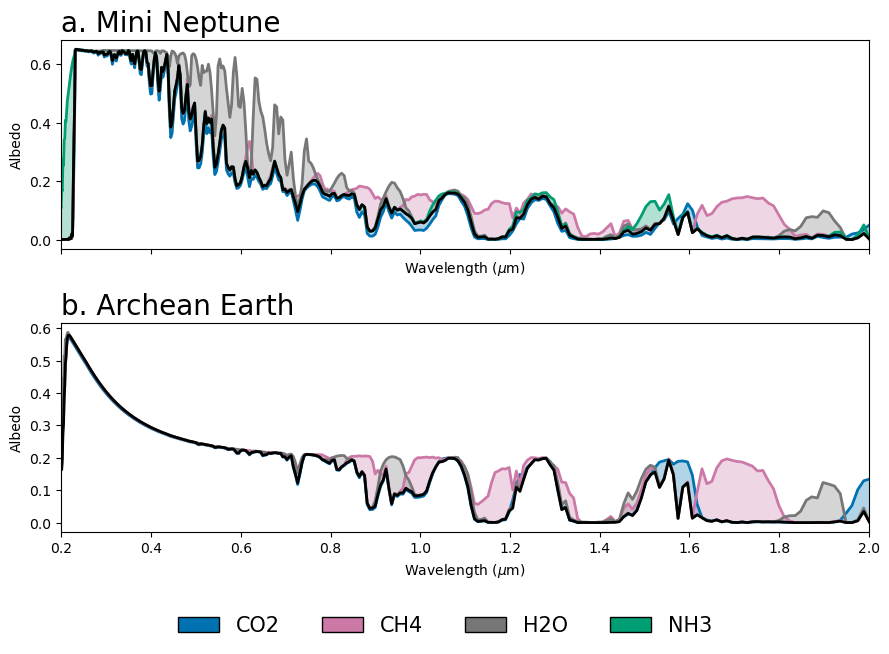

In [55]:
# AAS two-column width = 7.25 in; ~2.2 in per panel is comfortable for 4 panels

#Figure 1c:
wno_all_H2CORich_MinNep_gas = [c3_noCO2['wno'], c3_noCH4['wno'], c3_noH2O['wno'], c3_noNH3['wno'], c3_standard['wno']]
alb_all_H2CORich_MinNep_gas = [c3_noCO2['alb'], c3_noCH4['alb'], c3_noH2O['alb'], c3_noNH3['alb'], c3_standard['alb']]
inputs_all_H2CORich_MinNep_gas = [None, None, None, None, None]
legend_label_all_H2CORich_MinNep_gas = ['CO2', 'CH4', 'H2O', 'NH3', 'Mini Neptune'] # Means no CO2, no CH4, no H2O, no NH3

#Figure 1d:
wno_all_ArcheanEarth_gas = [wno_ArcheanEarth_phase0deg_noCO2, wno_ArcheanEarth_phase0deg_noCH4, wno_ArcheanEarth_phase0deg_noH2O, wno_ArcheanEarth_phase0deg,]
alb_all_ArcheanEarth_gas = [alb_ArcheanEarth_phase0deg_noCO2, alb_ArcheanEarth_phase0deg_noCH4, alb_ArcheanEarth_phase0deg_noH2O, alb_ArcheanEarth_phase0deg,]
inputs_all_ArcheanEarth_gas = [None, None, None, None]
legend_label_all_ArcheanEarth_gas = ['CO2', 'CH4', 'H2O', 'Archean Earth']


fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

plot_reflected_spectrum_final(wno=wno_all_H2CORich_MinNep_gas, alb=alb_all_H2CORich_MinNep_gas, inputs=inputs_all_H2CORich_MinNep_gas, legend_label=legend_label_all_H2CORich_MinNep_gas, fill_indices=[0,1,2,3], ax1=axes[0], fill_between_ref=True, fill_ref_index=4, colors=WONG_MiniNep_Gas, show_legend=False, show_xlabel=True)
plot_reflected_spectrum_final(wno=wno_all_ArcheanEarth_gas, alb=alb_all_ArcheanEarth_gas, inputs=inputs_all_ArcheanEarth_gas, legend_label=legend_label_all_ArcheanEarth_gas, fill_indices=[0,1,2], ax1=axes[1], fill_between_ref = True, fill_ref_index=3, colors=WONG_Archean_Gas, show_legend=False, show_xlabel=True)

axes[0].set_title("a. Mini Neptune", loc='left', fontsize=20)
axes[1].set_title("b. Archean Earth", loc='left', fontsize=20)

# Code to check specific features mentioned in paper
#axes[0].axvline(x=0.89, color='red', linestyle='--')
#axes[0].axvline(x=1.17, color='yellow', linestyle='--')
#axes[0].axvline(x=1, color='purple', linestyle='--')
#axes[0].axvline(x=1.7, color='pink', linestyle='--')
#axes[0].axvline(x=0.95, color='b', linestyle='--')
#axes[0].axvline(x=1.9, color='cyan', linestyle='--')
#axes[0].axhline(y=100, color='red', linestyle='--')

handles = []

labels = legend_label_all_H2CORich_MinNep_gas  # <-- source of truth
colors = WONG_MiniNep_Gas

for i in range(4):  # first four only
    handles.append(
        Patch(
            facecolor=colors[i],
            edgecolor="black",
            label=labels[i],
        )
    )

fig.legend(
    handles=handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    labelspacing=1.5,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=15
)

plt.subplots_adjust(hspace=0.08)
plt.tight_layout()
plt.savefig('FinalPaperFigs/H2CORichMinNep_ArcheanEarth_MoleculeContributionsFigure_UpdatedOpacity.pdf', dpi=300, bbox_inches='tight')

## Extra Case

#### Figure 1: Spaghetti Plot of Photochemistry and PT Profile of O2 Rich Mini-Neptune like K218b

In [56]:
rad_plan = 2.61
log10_metal = 3.5
tint = 155
semi_major = 1
ctoO = 0.01
Kzz = 5

In [57]:
sol_file_path = "sol_2.61_3.5_155_1_0.01_5.pkl"
soleq_file_path = "soleq_2.61_3.5_155_1_0.01_5.pkl"

with open(sol_file_path, 'rb') as file:
    photochem_data_35m_001co_sol = pickle.load(file)
    print(photochem_data_35m_001co_sol.keys())

with open(soleq_file_path, 'rb') as file:
    photochem_data_35m_001co_soleq = pickle.load(file)
    print(photochem_data_35m_001co_soleq.keys())

file_path = "out_3.5m_0.01co.pkl"
with open(file_path, 'rb') as file:
    data_35m_001co = pickle.load(file)
    print(data_35m_001co.keys())

dict_keys(['pressure', 'temperature', 'Kzz', 'H2Oaer', 'CO2aer', 'NH3aer', 'N2Oaer', 'C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'HCCCNaer', 'HCNaer', 'CH4aer', 'He', 'H', 'H2', 'H2O', 'OH', 'O', 'O2', 'CO', 'CO2', 'HCO', 'H2CO', 'C', 'CH', 'CH2', 'CH3', 'CH4', 'CN', 'HCN', 'N', 'N2', 'NH', 'NH2', 'NH3', 'C2', 'C2H', 'C2H2', 'C2H4', 'NO', 'HNO', 'HO2', 'HNCO', 'N2O', 'H2O2', 'O3', 'NO2', 'NO3', 'HNO2', 'HNO3', 'N2H4', 'C2H6', 'CH3OH', 'CH2CO', 'CH3CHO', 'C3H4', 'C3H6', 'C4H2', 'C4H4', 'C2H3', 'C2H5', 'NCO', '1CH2', 'HCCO', 'NNH', 'CH3O', 'H2COH', 'H2CN', 'N2H2', 'C4H', 'HCNOH', 'C2H2OH', 'CH3CO', 'CH2CHO', 'C2H3OH', 'C2H4OH', 'CH3O2', 'O1D', 'N2H3', 'NH2CO', 'C4H3', 'CH2N2', 'N2D', 'CH2CN', 'CH3CN', 'HCCCN'])
dict_keys(['pressure', 'temperature', 'Kzz', 'He', 'H', 'H2', 'H2O', 'OH', 'O', 'O2', 'CO', 'CO2', 'HCO', 'H2CO', 'C', 'CH', 'CH2', 'CH3', 'CH4', 'CN', 'HCN', 'N', 'N2', 'NH', 'NH2', 'NH3', 'C2', 'C2H', 'C2H2', 'C2H4', 'NO', 'HNO', 'HO2', 'HNCO', 'N2O', 'H2O2', 'O3', 'NO2', 'NO3'

In [58]:
photochem_data_case3 = {'sol_dict': photochem_data_35m_001co_sol,
                'soleq_dict': photochem_data_35m_001co_soleq,
                'pressure': data_35m_001co['pressure'],
                'temperature': data_35m_001co['temperature']}

top_keys, molecule_means = get_top_molecules_for_case(photochem_data=photochem_data_case3, top_n=12)
print(len(top_keys))
print(top_keys)

for top_key in top_keys:
    print(top_key, f'{molecule_means[f'{top_key}']}')

12
['O2', 'He', 'N2', 'CO2', 'O', 'O3', 'CO', 'NO', 'H2O', 'H', 'OH', 'CO2aer']
O2 0.6502156920262532
He 0.25939644193505923
N2 0.08215579367719497
CO2 0.00375031086549384
O 0.0011364654081327395
O3 3.017193657655884e-06
CO 1.8047318305607825e-06
NO 5.815364904033686e-07
H2O 2.925427422585251e-07
H 1.4787076345303616e-07
OH 1.0445823293642703e-07
CO2aer 4.2228199544653785e-08


dict_keys(['H2Oaer', 'CO2aer', 'NH3aer', 'N2Oaer', 'C2H2aer', 'C2H4aer', 'C2H6aer', 'CH3CNaer', 'HCCCNaer', 'HCNaer', 'CH4aer'])


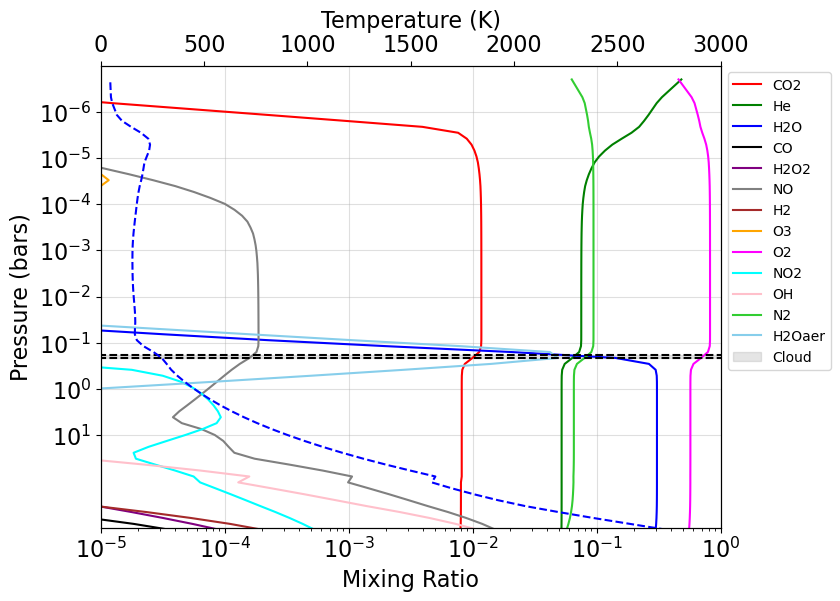

In [59]:
plot_photochem_model_with_cloud(sol=photochem_data_35m_001co_sol, soleq=photochem_data_35m_001co_soleq)